EDA

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn_version}")

Python: 3.13.3
NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [2]:
print(sys.executable)

c:\Users\andre\OneDrive\Documentos\POSTECH - IA Scientist\tech-challenge-fase3\.venv\Scripts\python.exe


## 1. Carregamento dos dados

In [3]:
DATA_PATH = "../data/processed/modeling_dataset_2024_gold.parquet"

df = pd.read_parquet(DATA_PATH)

print(f"Shape do dataset: {df.shape}")
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Shape do dataset: (1851828, 24)
Linhas: 1,851,828
Colunas: 24


## 2. Visão geral do dataset

In [4]:
print("Informações gerais do dataset:\n")
df.info()

Informações gerais do dataset:

<class 'pandas.DataFrame'>
RangeIndex: 1851828 entries, 0 to 1851827
Data columns (total 24 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   ano                                     Int64  
 1   id_aluno                                str    
 2   id_municipio                            str    
 3   id_escola                               str    
 4   rede                                    str    
 5   peso_aluno                              float64
 6   alfabetizado                            int8   
 7   id_municipio_nome                       str    
 8   taxa_alfabetizacao_municipio_2023       float32
 9   media_portugues_municipio_2023          float32
 10  percentual_participacao_municipio_2023  float32
 11  total_alunos_municipio_2023             float64
 12  pct_alfabetizados_municipio_2023        float64
 13  proficiencia_media_ponderada_2023       float64
 14  meta_alfabeti

In [5]:
print("Quantidade de valores únicos por coluna:\n")

unique_counts = (
    df.nunique(dropna=False)
    .sort_values(ascending=False)
)

unique_counts

Quantidade de valores únicos por coluna:



id_aluno                                  1851828
id_escola                                   42327
media_portugues_municipio_2023               6398
proficiencia_media_ponderada_2023            5688
id_municipio                                 5517
id_municipio_nome                            5210
taxa_alfabetizacao_municipio_2023            4060
pct_alfabetizados_municipio_2023             3496
meta_alfabetizacao_municipio_2024            2746
gap_para_meta_municipio_2024                 1924
percentual_participacao_municipio_2023       1725
total_alunos_municipio_2023                   978
peso_aluno                                    540
sigla_uf                                       25
sigla_uf_nome                                  25
idhm_renda                                     24
idhm_longevidade                               23
idhm                                           23
idhm_educacao                                  22
atingiu_meta_municipio_2024                     3


In [6]:
print("Distribuição dos alunos por rede:\n")

network_distribution = pd.DataFrame({
    "quantidade": df["rede"].value_counts(),
    "percentual": (
        df["rede"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ),
})

network_distribution

Distribuição dos alunos por rede:



,quantidade,percentual
rede,,
Municipal,1610754,86.98
Estadual,241074,13.02


## 3. Qualidade dos dados

In [7]:
missing_summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "percentual": (
        df.isna()
        .mean()
        .mul(100)
        .round(2)
    ),
})

missing_summary = (
    missing_summary
    .loc[missing_summary["nulos"] > 0]
    .sort_values(
        "percentual",
        ascending=False,
    )
)

missing_summary

,nulos,percentual
pct_alfabetizados_municipio_2023,429286,23.18
proficiencia_media_ponderada_2023,429286,23.18
total_alunos_municipio_2023,429286,23.18
percentual_participacao_municipio_2023,87097,4.70
meta_alfabetizacao_municipio_2024,87097,4.70
gap_para_meta_municipio_2024,87097,4.70
atingiu_meta_municipio_2024,87097,4.70
media_portugues_municipio_2023,35558,1.92
taxa_alfabetizacao_municipio_2023,35558,1.92
id_municipio_nome,35558,1.92


In [8]:
print("Alunos sem correspondência na Gold:")

print(
    df["gold_historico_disponivel"]
    .value_counts(dropna=False)
)

print("\nPercentual sem correspondência:")

print(
    (
        df["gold_historico_disponivel"]
        .eq(0)
        .mean()
        * 100
    ).round(2),
    "%"
)

Alunos sem correspondência na Gold:
gold_historico_disponivel
1    1816270
0      35558
Name: count, dtype: int64

Percentual sem correspondência:
1.92 %


In [9]:
print("UFs não nulas:")
print(df["sigla_uf"].nunique(dropna=True))

print("\nValores ausentes em sigla_uf:")
print(df["sigla_uf"].isna().sum())

print("\nDistribuição das UFs:")
print(
    df["sigla_uf"]
    .value_counts(dropna=False)
    .sort_index()
)

UFs não nulas:
24

Valores ausentes em sigla_uf:
35558

Distribuição das UFs:
sigla_uf
AL      31575
AM      46628
AP      11194
BA     104020
CE      88136
ES      42751
GO      70777
MA      62959
MG     180299
MS      37181
MT      45062
PA      83173
PB      30978
PE      75953
PI      31105
PR     119762
RJ     125536
RN      22786
RO      20027
RS      89058
SC      68981
SE      17802
SP     393728
TO      16799
NaN     35558
Name: count, dtype: int64


In [10]:
print("=== INTEGRIDADE E GRANULARIDADE ===")

print(
    "Linhas do dataset:",
    f"{len(df):,}"
)

print(
    "IDs de aluno únicos:",
    f"{df['id_aluno'].nunique():,}"
)

print(
    "Alunos duplicados:",
    df["id_aluno"].duplicated().sum()
)

print(
    "IDs de aluno nulos:",
    df["id_aluno"].isna().sum()
)

print(
    "Municípios nulos:",
    df["id_municipio"].isna().sum()
)

print(
    "Escolas nulas:",
    df["id_escola"].isna().sum()
)

print(
    "Target nulo:",
    df["alfabetizado"].isna().sum()
)

=== INTEGRIDADE E GRANULARIDADE ===
Linhas do dataset: 1,851,828
IDs de aluno únicos: 1,851,828
Alunos duplicados: 0
IDs de aluno nulos: 0
Municípios nulos: 0
Escolas nulas: 0
Target nulo: 0


In [11]:
print("=== VALIDAÇÕES DE DOMÍNIO ===")

print("\nAnos:")
print(df["ano"].value_counts(dropna=False))

print("\nRedes:")
print(df["rede"].value_counts(dropna=False))

print("\nTarget:")
print(df["alfabetizado"].value_counts(dropna=False))

print("\nGold disponível:")
print(
    df["gold_historico_disponivel"]
    .value_counts(dropna=False)
)

print("\nPeso do aluno:")
print(df["peso_aluno"].describe())

=== VALIDAÇÕES DE DOMÍNIO ===

Anos:
ano
2024    1851828
Name: count, dtype: Int64

Redes:
rede
Municipal    1610754
Estadual      241074
Name: count, dtype: int64

Target:
alfabetizado
1    1107103
0     744725
Name: count, dtype: int64

Gold disponível:
gold_historico_disponivel
1    1816270
0      35558
Name: count, dtype: int64

Peso do aluno:
count    1.851828e+06
mean     1.138956e+00
std      2.056983e-01
min      1.000000e+00
25%      1.030000e+00
50%      1.090000e+00
75%      1.190000e+00
max      2.983000e+01
Name: peso_aluno, dtype: float64


In [12]:
gold_core_columns = [
    "taxa_alfabetizacao_municipio_2023",
    "media_portugues_municipio_2023",
    "sigla_uf",
    "idhm",
]

print("=== CONSISTÊNCIA DA FLAG GOLD ===")

for column in gold_core_columns:
    missing_without_gold = df.loc[
        df["gold_historico_disponivel"] == 0,
        column,
    ].isna().mean()

    missing_with_gold = df.loc[
        df["gold_historico_disponivel"] == 1,
        column,
    ].isna().mean()

    print(f"\n{column}")
    print(
        f"  Sem Gold -> nulos: "
        f"{missing_without_gold * 100:.2f}%"
    )
    print(
        f"  Com Gold -> nulos: "
        f"{missing_with_gold * 100:.2f}%"
    )

=== CONSISTÊNCIA DA FLAG GOLD ===

taxa_alfabetizacao_municipio_2023
  Sem Gold -> nulos: 100.00%
  Com Gold -> nulos: 0.00%

media_portugues_municipio_2023
  Sem Gold -> nulos: 100.00%
  Com Gold -> nulos: 0.00%

sigla_uf
  Sem Gold -> nulos: 100.00%
  Com Gold -> nulos: 0.00%

idhm
  Sem Gold -> nulos: 100.00%
  Com Gold -> nulos: 0.00%


## 4. Análise da variável-alvo

In [13]:
target_summary = pd.DataFrame({
    "quantidade": (
        df["alfabetizado"]
        .value_counts()
        .sort_index()
    ),
    "percentual": (
        df["alfabetizado"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
})

target_summary.index = [
    "Não alfabetizado",
    "Alfabetizado",
]

target_summary

,quantidade,percentual
Não alfabetizado,744725,40.22
Alfabetizado,1107103,59.78


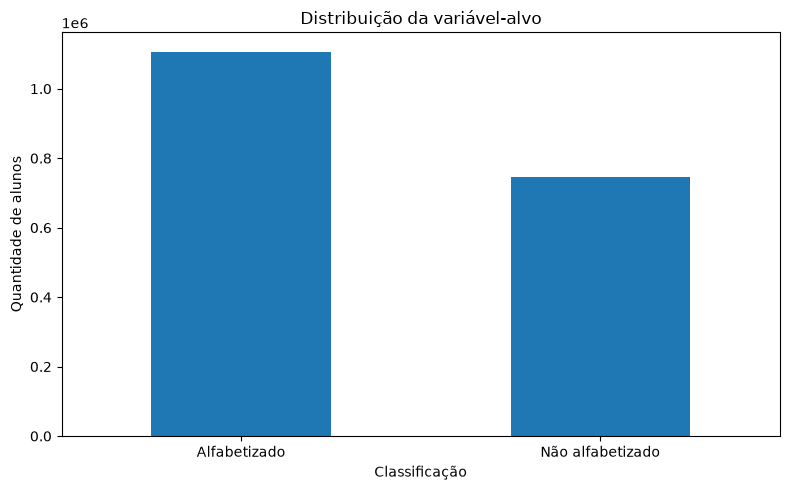

In [14]:
target_plot = (
    df["alfabetizado"]
    .map({
        0: "Não alfabetizado",
        1: "Alfabetizado",
    })
    .value_counts()
)

ax = target_plot.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Distribuição da variável-alvo"
)
ax.set_xlabel(
    "Classificação"
)
ax.set_ylabel(
    "Quantidade de alunos"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
target_by_network = pd.crosstab(
    df["rede"],
    df["alfabetizado"],
    normalize="index",
).mul(100)

target_by_network = target_by_network.rename(
    columns={
        0: "Não alfabetizado (%)",
        1: "Alfabetizado (%)",
    }
)

target_by_network.round(2)

alfabetizado,Não alfabetizado (%),Alfabetizado (%)
rede,,
Estadual,37.46,62.54
Municipal,40.63,59.37


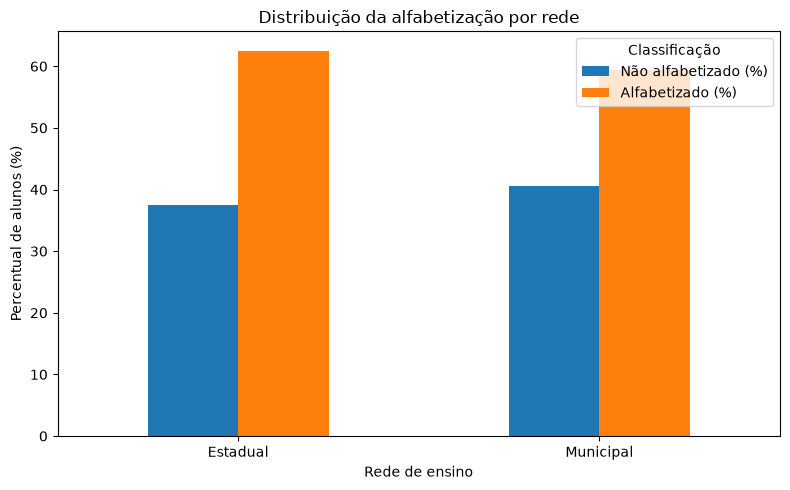

In [16]:
ax = target_by_network.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Distribuição da alfabetização por rede"
)
ax.set_xlabel(
    "Rede de ensino"
)
ax.set_ylabel(
    "Percentual de alunos (%)"
)

plt.xticks(rotation=0)
plt.legend(title="Classificação")
plt.tight_layout()
plt.show()

### Principais observações

A variável-alvo apresenta distribuição relativamente equilibrada, com 59,78% dos alunos classificados como alfabetizados e 40,22% como não alfabetizados. Dessa forma, não foi identificado desbalanceamento severo que justifique, neste momento, a aplicação de técnicas de reamostragem.

A análise por rede de ensino mostrou diferença na proporção de alunos alfabetizados: 62,54% na rede Estadual e 59,37% na rede Municipal. Essa diferença sugere que a rede pode apresentar capacidade explicativa para o modelo, embora sua relação com o resultado deva ser analisada em conjunto com características territoriais, educacionais e socioeconômicas.

## 5. Análise das variáveis numéricas

In [17]:
numeric_features = [
    "peso_aluno",
    "taxa_alfabetizacao_municipio_2023",
    "media_portugues_municipio_2023",
    "percentual_participacao_municipio_2023",
    "total_alunos_municipio_2023",
    "pct_alfabetizados_municipio_2023",
    "proficiencia_media_ponderada_2023",
    "meta_alfabetizacao_municipio_2024",
    "gap_para_meta_municipio_2024",
    "idhm",
    "idhm_educacao",
    "idhm_renda",
    "idhm_longevidade",
]

print(
    f"Quantidade de features numéricas: "
    f"{len(numeric_features)}"
)

numeric_features

Quantidade de features numéricas: 13


['peso_aluno',
 'taxa_alfabetizacao_municipio_2023',
 'media_portugues_municipio_2023',
 'percentual_participacao_municipio_2023',
 'total_alunos_municipio_2023',
 'pct_alfabetizados_municipio_2023',
 'proficiencia_media_ponderada_2023',
 'meta_alfabetizacao_municipio_2024',
 'gap_para_meta_municipio_2024',
 'idhm',
 'idhm_educacao',
 'idhm_renda',
 'idhm_longevidade']

In [18]:
numeric_summary = (
    df[numeric_features]
    .describe()
    .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
peso_aluno,1851828.0,1.138956,0.205698,1.000000,1.030000,1.090000,1.190000,29.830000
taxa_alfabetizacao_municipio_2023,1816270.0,56.634426,15.548287,3.410000,46.689999,56.189999,65.949997,100.000000
media_portugues_municipio_2023,1816270.0,745.599670,20.118999,673.298279,733.881226,743.274414,754.093018,868.455383
percentual_participacao_municipio_2023,1764731.0,87.011398,5.914391,70.000000,83.449997,87.089996,91.199997,100.000000
total_alunos_municipio_2023,1422542.0,4316.190116,10038.911647,10.000000,270.000000,848.000000,3401.000000,54533.000000
pct_alfabetizados_municipio_2023,1422542.0,50.962455,16.392831,3.571400,38.843000,49.543000,60.396000,100.000000
proficiencia_media_ponderada_2023,1422542.0,747.025369,21.270548,673.298300,734.476300,744.366400,756.421100,868.455400
meta_alfabetizacao_municipio_2024,1764731.0,59.157848,12.398882,7.940000,49.840000,59.250000,68.180000,80.000000
gap_para_meta_municipio_2024,1764731.0,2.341105,5.604141,-61.270000,1.500000,3.820000,5.450000,71.190000
idhm,1816270.0,0.795056,0.032825,0.739000,0.763000,0.803000,0.821000,0.836000


In [19]:
numeric_quality = pd.DataFrame({
    "media": df[numeric_features].mean(),
    "mediana": df[numeric_features].median(),
    "desvio_padrao": df[numeric_features].std(),
    "minimo": df[numeric_features].min(),
    "maximo": df[numeric_features].max(),
    "nulos_percentual": (
        df[numeric_features]
        .isna()
        .mean()
        .mul(100)
    ),
})

numeric_quality.round(2)

,media,mediana,desvio_padrao,minimo,maximo,nulos_percentual
peso_aluno,1.14,1.09,0.21,1.00,29.83,0.00
taxa_alfabetizacao_municipio_2023,56.63,56.19,15.55,3.41,100.00,1.92
media_portugues_municipio_2023,745.60,743.27,20.12,673.30,868.46,1.92
percentual_participacao_municipio_2023,87.01,87.09,5.91,70.00,100.00,4.70
total_alunos_municipio_2023,4316.19,848.00,10038.91,10.00,54533.00,23.18
pct_alfabetizados_municipio_2023,50.96,49.54,16.39,3.57,100.00,23.18
proficiencia_media_ponderada_2023,747.03,744.37,21.27,673.30,868.46,23.18
meta_alfabetizacao_municipio_2024,59.16,59.25,12.40,7.94,80.00,4.70
gap_para_meta_municipio_2024,2.34,3.82,5.60,-61.27,71.19,4.70
idhm,0.80,0.80,0.03,0.74,0.84,1.92


Histogramas

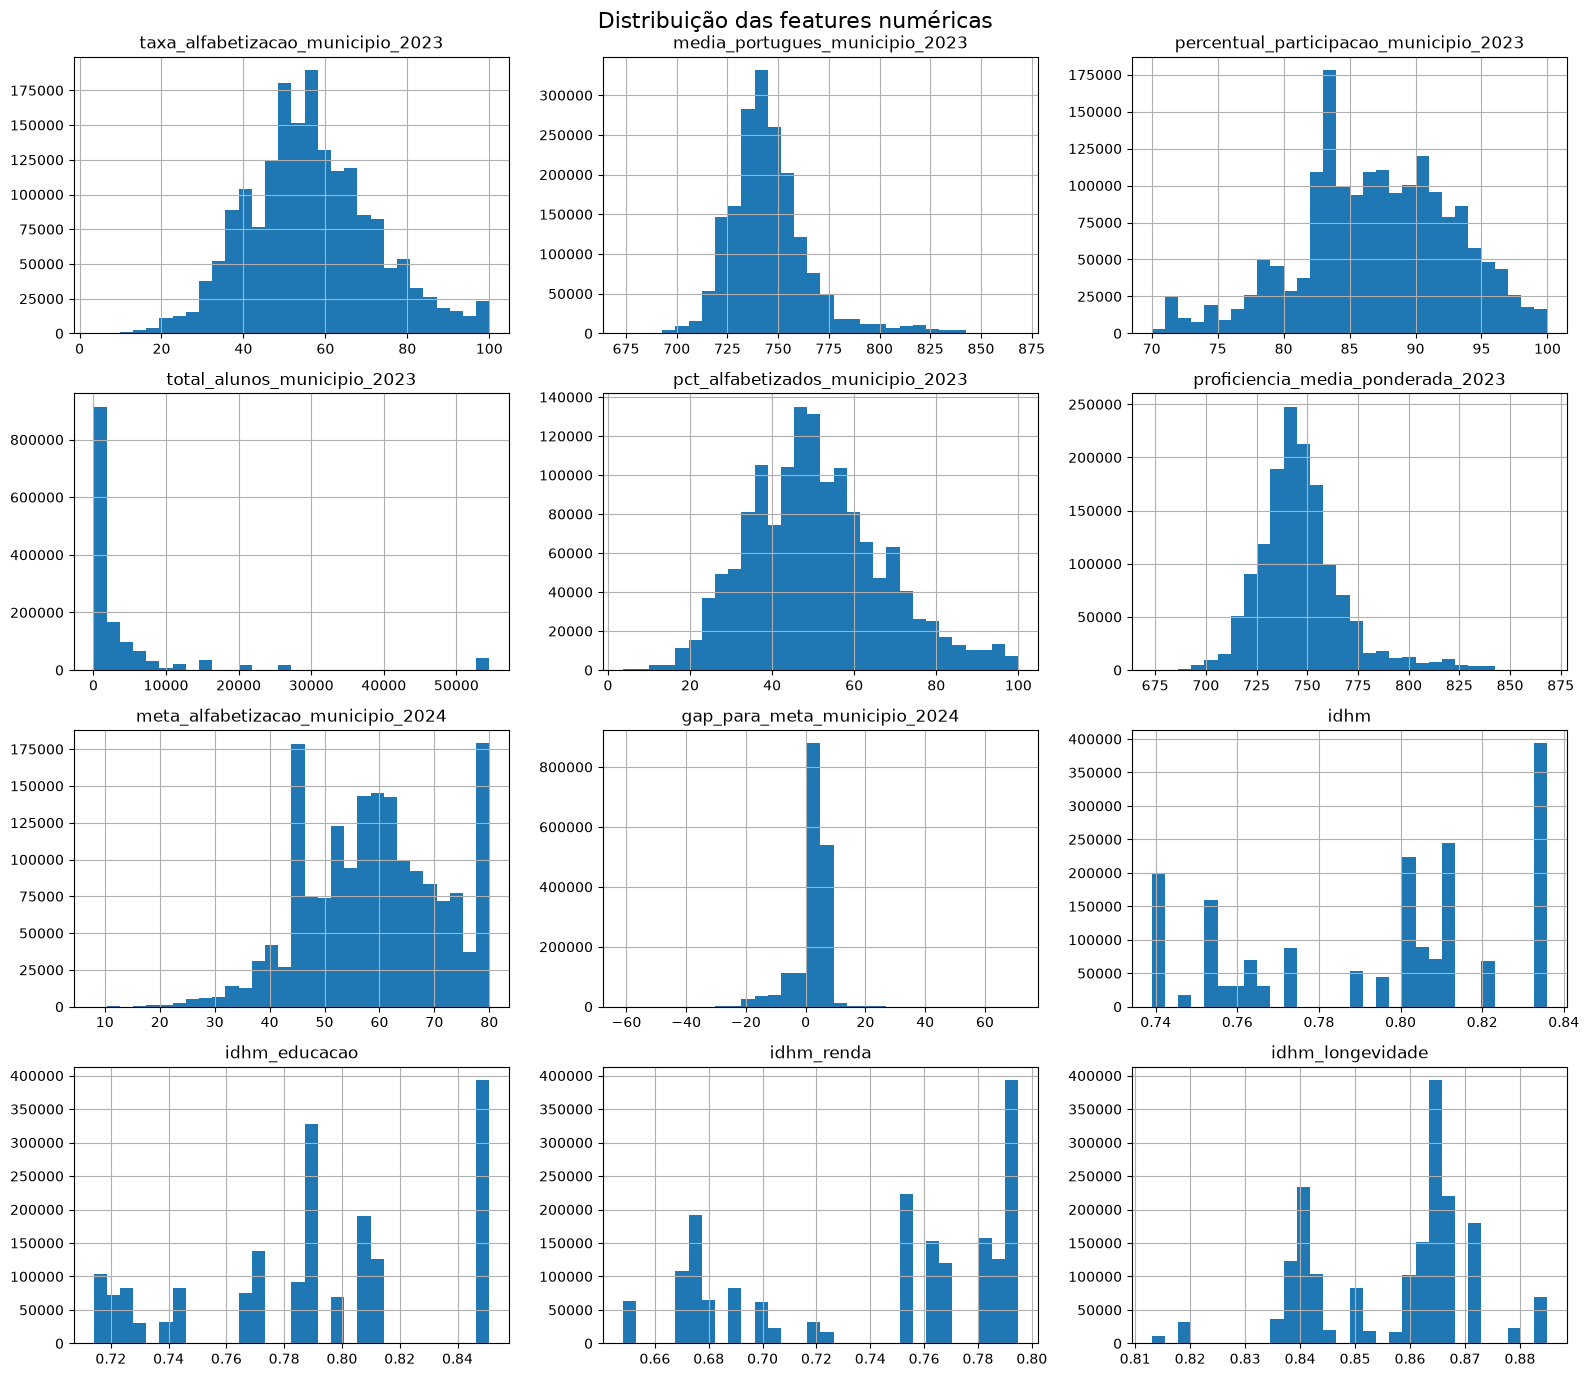

In [20]:
features_to_plot = [
    "taxa_alfabetizacao_municipio_2023",
    "media_portugues_municipio_2023",
    "percentual_participacao_municipio_2023",
    "total_alunos_municipio_2023",
    "pct_alfabetizados_municipio_2023",
    "proficiencia_media_ponderada_2023",
    "meta_alfabetizacao_municipio_2024",
    "gap_para_meta_municipio_2024",
    "idhm",
    "idhm_educacao",
    "idhm_renda",
    "idhm_longevidade",
]

df[features_to_plot].hist(
    bins=30,
    figsize=(16, 14),
)

plt.suptitle(
    "Distribuição das features numéricas",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [21]:
skewness = (
    df[numeric_features]
    .skew()
    .sort_values(ascending=False)
    .to_frame("assimetria")
)

skewness.round(2)

,assimetria
peso_aluno,22.84
total_alunos_municipio_2023,4.01
media_portugues_municipio_2023,1.33
proficiencia_media_ponderada_2023,1.22
pct_alfabetizados_municipio_2023,0.43
taxa_alfabetizacao_municipio_2023,0.30
meta_alfabetizacao_municipio_2024,-0.11
idhm_educacao,-0.16
percentual_participacao_municipio_2023,-0.29
idhm,-0.37


### Principais observações

As variáveis numéricas apresentam diferentes padrões de distribuição. A maior assimetria foi observada em `peso_aluno` e `total_alunos_municipio_2023`, indicando a presença de valores elevados em relação à maior parte das observações. Esses casos serão investigados especificamente na análise de outliers antes de qualquer decisão de tratamento.

As variáveis relacionadas à proficiência apresentam assimetria positiva moderada e distribuições visualmente semelhantes, reforçando a necessidade de avaliar posteriormente possível redundância entre `media_portugues_municipio_2023` e `proficiencia_media_ponderada_2023`.

As variáveis de IDHM apresentam distribuições discretas, resultado esperado da granularidade estadual dessas informações: o mesmo indicador socioeconômico é compartilhado pelos alunos pertencentes à mesma unidade federativa.

A variável `gap_para_meta_municipio_2024` apresenta assimetria negativa mais acentuada e valores extremos em ambas as direções, aspecto que será aprofundado na análise de outliers.

Nenhuma transformação ou remoção de observações foi realizada nesta etapa. Eventuais transformações serão avaliadas posteriormente de acordo com o algoritmo utilizado e incorporadas ao pipeline de modelagem quando necessárias.

## 6. Análise das variáveis categóricas

In [22]:
categorical_features = [
    "rede",
    "sigla_uf",
    "atingiu_meta_municipio_2024",
]

for column in categorical_features:
    print(f"\n=== {column} ===")
    print(
        df[column]
        .value_counts(
            dropna=False,
            normalize=True,
        )
        .mul(100)
        .round(2)
    )


=== rede ===
rede
Municipal    86.98
Estadual     13.02
Name: proportion, dtype: float64

=== sigla_uf ===
sigla_uf
SP     21.26
MG      9.74
RJ      6.78
PR      6.47
BA      5.62
RS      4.81
CE      4.76
PA      4.49
PE      4.10
GO      3.82
SC      3.73
MA      3.40
AM      2.52
MT      2.43
ES      2.31
MS      2.01
NaN     1.92
AL      1.71
PI      1.68
PB      1.67
RN      1.23
RO      1.08
SE      0.96
TO      0.91
AP      0.60
Name: proportion, dtype: float64

=== atingiu_meta_municipio_2024 ===
atingiu_meta_municipio_2024
False    80.20
True     15.09
None      4.70
Name: proportion, dtype: float64


In [23]:
literacy_by_state = (
    df.dropna(subset=["sigla_uf"])
    .groupby("sigla_uf", observed=True)
    .agg(
        total_alunos=("id_aluno", "size"),
        taxa_alfabetizados=(
            "alfabetizado",
            "mean",
        ),
    )
    .reset_index()
)

literacy_by_state[
    "taxa_alfabetizados"
] *= 100

literacy_by_state = (
    literacy_by_state
    .sort_values(
        "taxa_alfabetizados",
        ascending=False,
    )
)

literacy_by_state.round(2)

,sigla_uf,total_alunos,taxa_alfabetizados
4,CE,88136,85.33
6,GO,70777,73.02
8,MG,180299,72.57
5,ES,42751,72.09
15,PR,119762,70.80
20,SC,68981,63.65
18,RO,20027,63.02
13,PE,75953,61.07
10,MT,45062,60.98
14,PI,31105,60.27


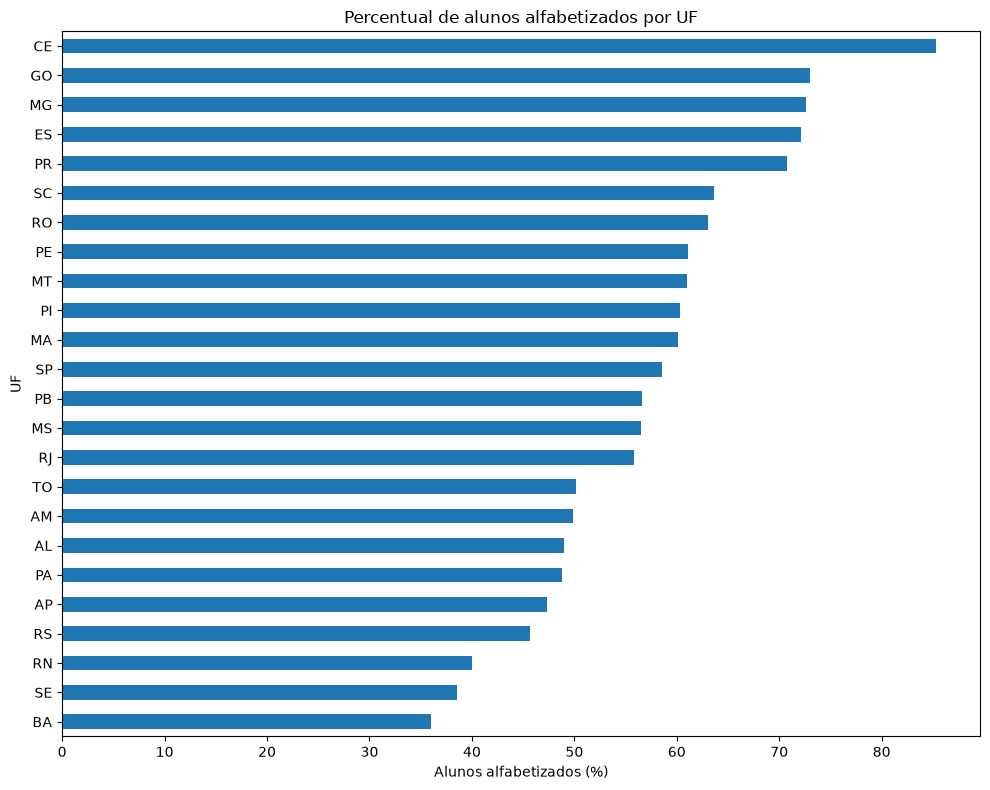

In [24]:
ax = (
    literacy_by_state
    .set_index("sigla_uf")[
        "taxa_alfabetizados"
    ]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(10, 8),
    )
)

ax.set_title(
    "Percentual de alunos alfabetizados por UF"
)
ax.set_xlabel(
    "Alunos alfabetizados (%)"
)
ax.set_ylabel(
    "UF"
)

plt.tight_layout()
plt.show()

### Principais observações

A população analisada apresenta predominância da rede Municipal (86,98%), enquanto a rede Estadual representa 13,02% dos alunos.

A análise territorial mostrou diferenças expressivas na proporção de alunos classificados como alfabetizados entre as UFs presentes no dataset. Entre os alunos com contexto territorial disponível, o Ceará apresentou a maior proporção observada de alfabetizados (85,33%), enquanto a Bahia apresentou a menor (35,97%).

Esses valores representam exclusivamente a população presente no dataset de modelagem e não devem ser interpretados como estimativas oficiais das taxas estaduais de alfabetização.

As diferenças observadas sugerem que características territoriais podem apresentar capacidade explicativa relevante. Entretanto, fatores territoriais não devem ser interpretados isoladamente, pois podem refletir diferenças educacionais, socioeconômicas e de composição das redes de ensino.

A variável `atingiu_meta_municipio_2024` será submetida posteriormente à análise específica de data leakage antes de qualquer inclusão no conjunto de features do modelo.

## 7. Análise de outliers

In [25]:
peso_quantiles = df["peso_aluno"].quantile(
    [
        0.50,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
        0.9999,
        1.00,
    ]
)

peso_quantiles

0.5000     1.090000
0.9000     1.320000
0.9500     1.430000
0.9900     1.790000
0.9950     2.000000
0.9990     2.880000
0.9999     5.668173
1.0000    29.830000
Name: peso_aluno, dtype: float64

In [26]:
print("Registros com peso > 2:")
print((df["peso_aluno"] > 2).sum())

print("\nRegistros com peso > 3:")
print((df["peso_aluno"] > 3).sum())

print("\nRegistros com peso > 5:")
print((df["peso_aluno"] > 5).sum())

print("\nRegistros com peso > 10:")
print((df["peso_aluno"] > 10).sum())

print("\nMaiores pesos encontrados:")

print(
    df[
        [
            "peso_aluno",
            "rede",
            "sigla_uf",
            "alfabetizado",
        ]
    ]
    .sort_values(
        "peso_aluno",
        ascending=False,
    )
    .head(20)
)

Registros com peso > 2:
8654

Registros com peso > 3:
1562

Registros com peso > 5:
266

Registros com peso > 10:
44

Maiores pesos encontrados:
         peso_aluno       rede sigla_uf  alfabetizado
221539        29.83  Municipal       SC             0
61613         29.83  Municipal       SC             0
127763        29.83  Municipal       SC             0
798306        29.83  Municipal       SC             0
998861        26.85  Municipal       SC             0
611035        26.85  Municipal       SC             0
1229223       23.66  Municipal       SC             0
1547663       22.16  Municipal       SC             0
160004        22.16  Municipal       SC             0
771533        22.16  Municipal       SC             0
229613        22.00  Municipal       RJ             1
189204        20.78  Municipal       AM             0
1550251       20.78  Municipal       AM             0
373209        20.78  Municipal       AM             0
101278        18.31  Municipal       SC      

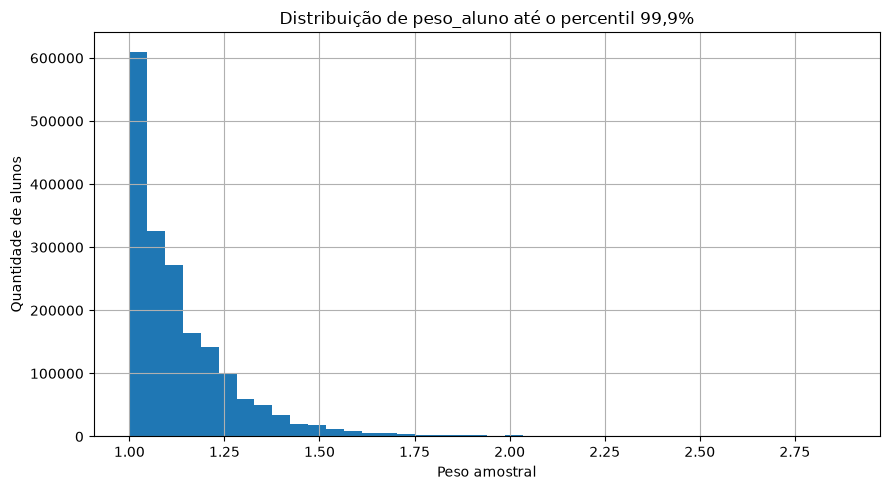

In [27]:
ax = df.loc[
    df["peso_aluno"] <= df["peso_aluno"].quantile(0.999),
    "peso_aluno",
].hist(
    bins=40,
    figsize=(9, 5),
)

ax.set_title(
    "Distribuição de peso_aluno até o percentil 99,9%"
)
ax.set_xlabel("Peso amostral")
ax.set_ylabel("Quantidade de alunos")

plt.tight_layout()
plt.show()

In [28]:
total_alunos_quantiles = (
    df["total_alunos_municipio_2023"]
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.995,
            0.999,
            1.00,
        ]
    )
)

total_alunos_quantiles

0.500      848.0
0.750     3401.0
0.900    10853.0
0.950    20027.0
0.990    54533.0
0.995    54533.0
0.999    54533.0
1.000    54533.0
Name: total_alunos_municipio_2023, dtype: float64

In [29]:
print("Registros com total > 5.000:")
print(
    (
        df["total_alunos_municipio_2023"]
        > 5_000
    ).sum()
)

print("\nRegistros com total > 10.000:")
print(
    (
        df["total_alunos_municipio_2023"]
        > 10_000
    ).sum()
)

print("\nRegistros com total > 25.000:")
print(
    (
        df["total_alunos_municipio_2023"]
        > 25_000
    ).sum()
)

print("\nRegistros com total > 50.000:")
print(
    (
        df["total_alunos_municipio_2023"]
        > 50_000
    ).sum()
)

Registros com total > 5.000:
264973

Registros com total > 10.000:
144515

Registros com total > 25.000:
62006

Registros com total > 50.000:
43340


In [30]:
municipality_size = (
    df[
        [
            "id_municipio",
            "id_municipio_nome",
            "rede",
            "sigla_uf",
            "total_alunos_municipio_2023",
        ]
    ]
    .dropna(
        subset=["total_alunos_municipio_2023"]
    )
    .drop_duplicates(
        subset=["id_municipio", "rede"]
    )
)

print(
    "Combinações município/rede:",
    len(municipality_size),
)

print("\nMaiores valores:")

print(
    municipality_size
    .sort_values(
        "total_alunos_municipio_2023",
        ascending=False,
    )
    .head(20)
    .to_string(index=False)
)

Combinações município/rede: 5712

Maiores valores:
id_municipio    id_municipio_nome      rede sigla_uf  total_alunos_municipio_2023
     3304557       Rio de Janeiro Municipal       RJ                      54533.0
     1302603               Manaus Municipal       AM                      26567.0
     2304400            Fortaleza Municipal       CE                      20027.0
     4106902             Curitiba Municipal       PR                      16016.0
     2927408             Salvador Municipal       BA                      15977.0
     3106200       Belo Horizonte Municipal       MG                      14853.0
     5002704         Campo Grande Municipal       MS                      11126.0
     2611606               Recife Municipal       PE                      11079.0
     5208707              Goiânia Municipal       GO                      10853.0
     3301702      Duque de Caxias Municipal       RJ                       8569.0
     3303500          Nova Iguaçu Municipal    

### Principais observações

A análise de outliers indicou que valores extremos não devem ser removidos automaticamente.

A variável `peso_aluno` apresenta forte assimetria positiva, porém os valores elevados representam uma parcela muito pequena da população. Aproximadamente 99,9% dos registros apresentam peso de até 2,88, enquanto apenas 44 alunos possuem peso superior a 10. Como a variável representa ponderação amostral, esses valores foram preservados e seu uso como possível `sample_weight`, em vez de feature preditiva, será avaliado na etapa de modelagem.

A variável `total_alunos_municipio_2023` também apresenta forte assimetria positiva. Entretanto, a análise no grão município/rede mostrou que os maiores valores estão associados principalmente a grandes redes municipais, como Rio de Janeiro, Manaus, Fortaleza, Curitiba e Salvador. Dessa forma, esses valores representam diferenças reais de escala entre redes de ensino e não foram considerados erros ou removidos.

Nenhum tratamento de outliers foi aplicado nesta etapa. Eventuais transformações serão avaliadas posteriormente de acordo com as necessidades dos algoritmos utilizados.

## 8. Relações entre features e target

In [31]:
target_numeric_comparison = (
    df.groupby("alfabetizado")[
        numeric_features
    ]
    .mean()
    .T
)

target_numeric_comparison.columns = [
    "Não alfabetizado",
    "Alfabetizado",
]

target_numeric_comparison[
    "diferença"
] = (
    target_numeric_comparison["Alfabetizado"]
    - target_numeric_comparison["Não alfabetizado"]
)

target_numeric_comparison.round(3)

,Não alfabetizado,Alfabetizado,diferença
peso_aluno,1.156,1.128,-0.028
taxa_alfabetizacao_municipio_2023,51.968,59.768,7.800
media_portugues_municipio_2023,739.540,749.668,10.128
percentual_participacao_municipio_2023,85.996,87.682,1.686
total_alunos_municipio_2023,4309.421,4320.669,11.248
pct_alfabetizados_municipio_2023,45.354,54.673,9.319
proficiencia_media_ponderada_2023,740.000,751.674,11.674
meta_alfabetizacao_municipio_2024,55.727,61.425,5.697
gap_para_meta_municipio_2024,3.589,1.516,-2.073
idhm,0.792,0.797,0.005


In [32]:
target_median_comparison = (
    df.groupby("alfabetizado")[
        numeric_features
    ]
    .median()
    .T
)

target_median_comparison.columns = [
    "Não alfabetizado",
    "Alfabetizado",
]

target_median_comparison[
    "diferença"
] = (
    target_median_comparison["Alfabetizado"]
    - target_median_comparison["Não alfabetizado"]
)

target_median_comparison.round(3)

,Não alfabetizado,Alfabetizado,diferença
peso_aluno,1.110,1.083,-0.027
taxa_alfabetizacao_municipio_2023,51.560,58.000,6.440
media_portugues_municipio_2023,738.886,746.358,7.471
percentual_participacao_municipio_2023,86.070,87.820,1.750
total_alunos_municipio_2023,956.000,789.000,-167.000
pct_alfabetizados_municipio_2023,44.746,53.065,8.319
proficiencia_media_ponderada_2023,740.024,748.468,8.445
meta_alfabetizacao_municipio_2024,56.040,61.180,5.140
gap_para_meta_municipio_2024,4.510,3.290,-1.220
idhm,0.803,0.803,0.000


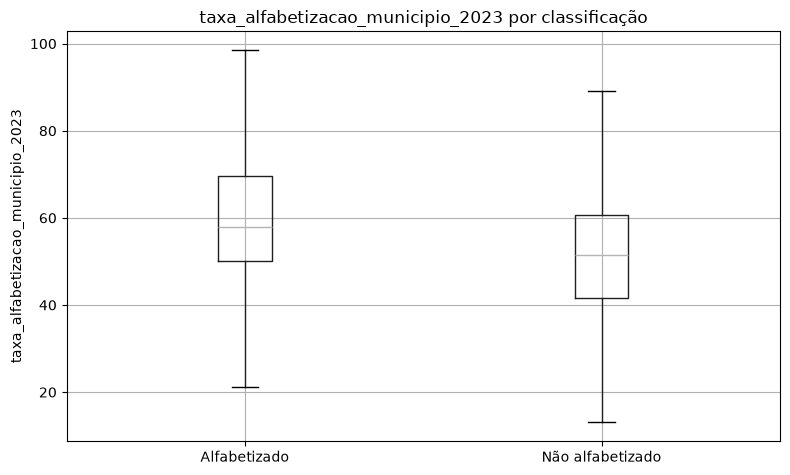

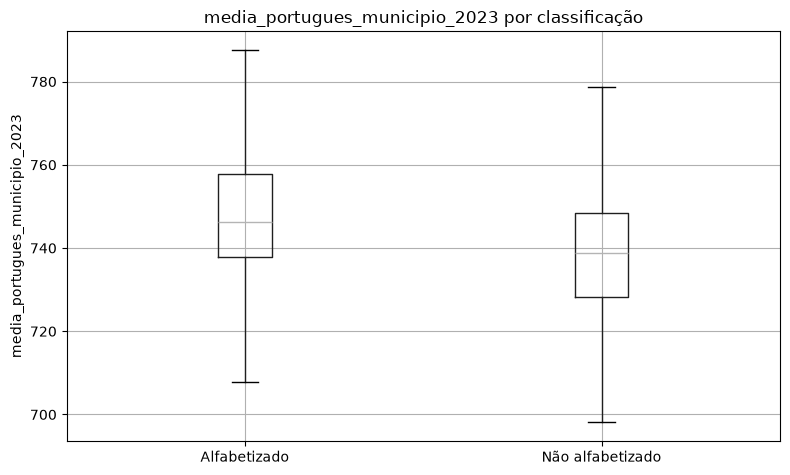

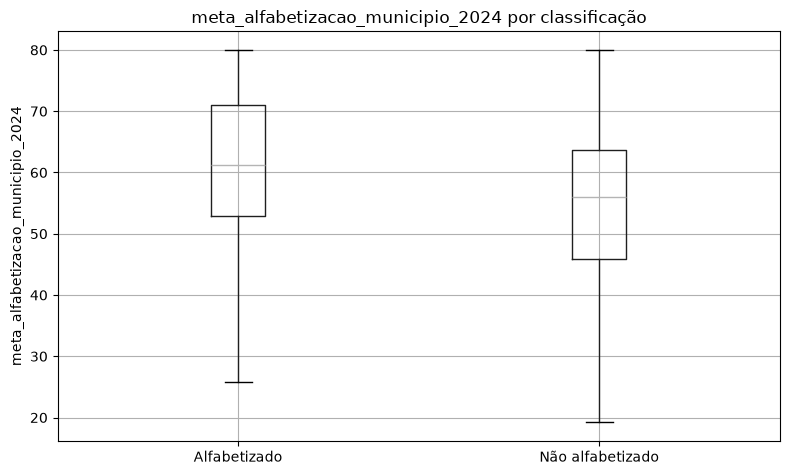

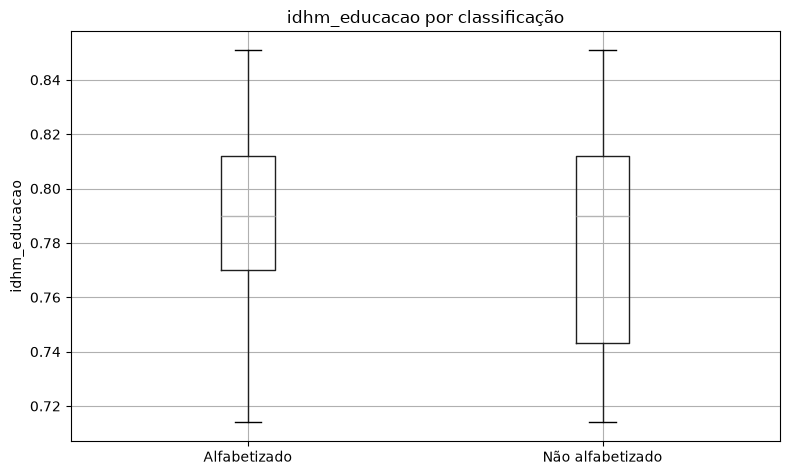

In [33]:
comparison_features = [
    "taxa_alfabetizacao_municipio_2023",
    "media_portugues_municipio_2023",
    "meta_alfabetizacao_municipio_2024",
    "idhm_educacao",
]

plot_df = df[
    comparison_features
    + ["alfabetizado"]
].copy()

plot_df["classificacao"] = (
    plot_df["alfabetizado"]
    .map({
        0: "Não alfabetizado",
        1: "Alfabetizado",
    })
)

for feature in comparison_features:
    ax = plot_df.boxplot(
        column=feature,
        by="classificacao",
        figsize=(8, 5),
        showfliers=False,
    )

    ax.set_title(
        f"{feature} por classificação"
    )
    ax.set_xlabel("")
    ax.set_ylabel(feature)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

### Relação entre contexto histórico e alfabetização

A comparação entre alunos alfabetizados e não alfabetizados indica associação relevante entre o resultado individual de 2024 e o contexto educacional histórico do município/rede.

Os alunos classificados como alfabetizados estão associados, em média, a municípios/redes que apresentavam em 2023 maiores taxas de alfabetização, maior proficiência média em Português e maior percentual de alunos alfabetizados. A taxa histórica de alfabetização apresentou diferença média de aproximadamente 7,8 pontos percentuais entre os grupos, enquanto o percentual histórico de alfabetizados apresentou diferença de aproximadamente 9,3 pontos percentuais.

As distribuições apresentam sobreposição significativa, indicando que nenhuma dessas variáveis isoladamente determina a classificação individual. Entretanto, as diferenças observadas sugerem capacidade preditiva potencial quando utilizadas em conjunto com outras características.

Os indicadores socioeconômicos estaduais apresentaram diferenças menores entre as classes. Como essas variáveis possuem granularidade estadual e são compartilhadas por grande número de alunos, sua contribuição deverá ser avaliada em conjunto com fatores territoriais e educacionais.

As relações observadas são associativas e não devem ser interpretadas como evidência de causalidade.

In [34]:
historical_rate_analysis = df[
    [
        "taxa_alfabetizacao_municipio_2023",
        "alfabetizado",
    ]
].dropna().copy()

historical_rate_analysis[
    "quintil_taxa_2023"
] = pd.qcut(
    historical_rate_analysis[
        "taxa_alfabetizacao_municipio_2023"
    ],
    q=5,
    duplicates="drop",
)

literacy_by_historical_quintile = (
    historical_rate_analysis
    .groupby(
        "quintil_taxa_2023",
        observed=True,
    )
    .agg(
        total_alunos=("alfabetizado", "size"),
        taxa_alfabetizados_2024=(
            "alfabetizado",
            "mean",
        ),
    )
    .reset_index()
)

literacy_by_historical_quintile[
    "taxa_alfabetizados_2024"
] *= 100

literacy_by_historical_quintile

,quintil_taxa_2023,total_alunos,taxa_alfabetizados_2024
0,"(3.4090000000000003, 43.33]",364086,42.597903
1,"(43.33, 52.06]",364094,54.685603
2,"(52.06, 58.91]",361680,59.800653
3,"(58.91, 69.15]",364554,65.078699
4,"(69.15, 100.0]",361856,77.073753


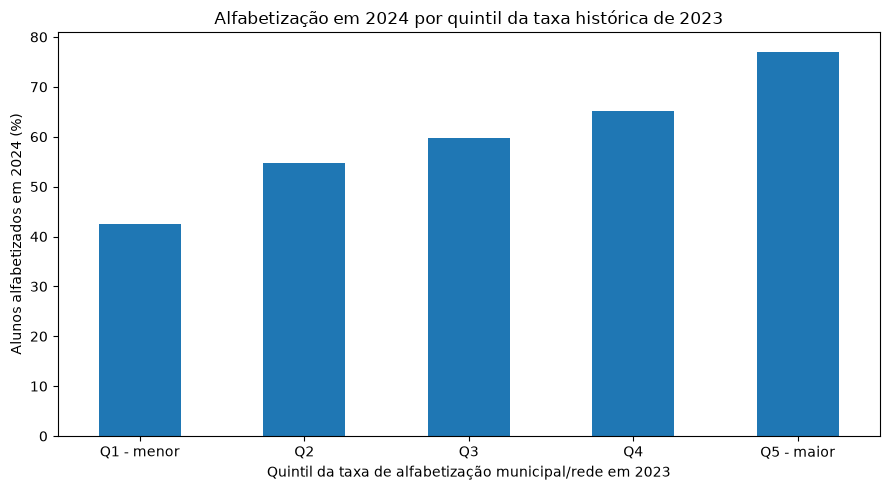

In [35]:
plot_quintiles = (
    literacy_by_historical_quintile
    .copy()
)

plot_quintiles["quintil"] = [
    "Q1 - menor",
    "Q2",
    "Q3",
    "Q4",
    "Q5 - maior",
]

ax = plot_quintiles.plot(
    x="quintil",
    y="taxa_alfabetizados_2024",
    kind="bar",
    legend=False,
    figsize=(9, 5),
)

ax.set_title(
    "Alfabetização em 2024 por quintil da taxa histórica de 2023"
)
ax.set_xlabel(
    "Quintil da taxa de alfabetização municipal/rede em 2023"
)
ax.set_ylabel(
    "Alunos alfabetizados em 2024 (%)"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Relação temporal do contexto educacional

A segmentação dos alunos em quintis de acordo com a taxa histórica de alfabetização do município/rede em 2023 revelou uma relação monotônica com a classificação individual observada em 2024.

Entre os alunos associados ao menor quintil da taxa histórica, 42,60% foram classificados como alfabetizados em 2024. Essa proporção aumenta progressivamente nos quintis seguintes, alcançando 77,07% entre os alunos associados ao maior quintil histórico.

A diferença entre os extremos é de aproximadamente 34,5 pontos percentuais, indicando forte associação entre o contexto educacional histórico do município/rede e o resultado individual no período seguinte.

Esse resultado reforça a relevância das features históricas provenientes da camada Gold para o problema preditivo. A relação observada é associativa e não deve ser interpretada como evidência de causalidade.

## 9. Correlações

In [36]:
correlation_features = [
    "taxa_alfabetizacao_municipio_2023",
    "media_portugues_municipio_2023",
    "percentual_participacao_municipio_2023",
    "total_alunos_municipio_2023",
    "pct_alfabetizados_municipio_2023",
    "proficiencia_media_ponderada_2023",
    "meta_alfabetizacao_municipio_2024",
    "gap_para_meta_municipio_2024",
    "idhm",
    "idhm_educacao",
    "idhm_renda",
    "idhm_longevidade",
    "alfabetizado",
]

correlation_matrix = (
    df[correlation_features]
    .corr(method="pearson")
)

correlation_matrix.round(3)

,taxa_alfabetizacao_municipio_2023,media_portugues_municipio_2023,percentual_participacao_municipio_2023,total_alunos_municipio_2023,pct_alfabetizados_municipio_2023,proficiencia_media_ponderada_2023,meta_alfabetizacao_municipio_2024,gap_para_meta_municipio_2024,idhm,idhm_educacao,idhm_renda,idhm_longevidade,alfabetizado
taxa_alfabetizacao_municipio_2023,1.000,0.941,0.343,-0.035,0.971,0.935,0.945,-0.688,0.155,0.174,0.067,0.295,0.246
media_portugues_municipio_2023,0.941,1.000,0.434,-0.070,0.945,0.999,0.855,-0.722,0.065,0.124,-0.053,0.278,0.247
percentual_participacao_municipio_2023,0.343,0.434,1.000,-0.260,0.519,0.447,0.340,-0.201,-0.044,0.037,-0.139,0.107,0.140
total_alunos_municipio_2023,-0.035,-0.070,-0.260,1.000,-0.083,-0.069,-0.012,0.086,0.150,0.232,0.160,-0.200,0.001
pct_alfabetizados_municipio_2023,0.971,0.945,0.519,-0.083,1.000,0.945,0.922,-0.766,0.279,0.399,0.104,0.337,0.278
proficiencia_media_ponderada_2023,0.935,0.999,0.447,-0.069,0.945,1.000,0.861,-0.790,0.216,0.356,0.027,0.343,0.269
meta_alfabetizacao_municipio_2024,0.945,0.855,0.340,-0.012,0.922,0.861,1.000,-0.411,0.135,0.131,0.068,0.282,0.225
gap_para_meta_municipio_2024,-0.688,-0.722,-0.201,0.086,-0.766,-0.790,-0.411,1.000,-0.113,-0.164,-0.016,-0.242,-0.181
idhm,0.155,0.065,-0.044,0.150,0.279,0.216,0.135,-0.113,1.000,0.926,0.957,0.546,0.074
idhm_educacao,0.174,0.124,0.037,0.232,0.399,0.356,0.131,-0.164,0.926,1.000,0.804,0.379,0.092


In [37]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1,
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlacao",
]

corr_pairs[
    "correlacao_absoluta"
] = (
    corr_pairs["correlacao"]
    .abs()
)

high_correlations = (
    corr_pairs
    .loc[
        corr_pairs[
            "correlacao_absoluta"
        ] >= 0.70
    ]
    .sort_values(
        "correlacao_absoluta",
        ascending=False,
    )
)

high_correlations.round(3)

,feature_1,feature_2,correlacao,correlacao_absoluta
18,media_portugues_municipio_2023,proficiencia_media_ponderada_2023,0.999,0.999
4,taxa_alfabetizacao_municipio_2023,pct_alfabetizados_municipio_2023,0.971,0.971
114,idhm,idhm_renda,0.957,0.957
57,pct_alfabetizados_municipio_2023,proficiencia_media_ponderada_2023,0.945,0.945
17,media_portugues_municipio_2023,pct_alfabetizados_municipio_2023,0.945,0.945
6,taxa_alfabetizacao_municipio_2023,meta_alfabetizacao_municipio_2024,0.945,0.945
1,taxa_alfabetizacao_municipio_2023,media_portugues_municipio_2023,0.941,0.941
5,taxa_alfabetizacao_municipio_2023,proficiencia_media_ponderada_2023,0.935,0.935
113,idhm,idhm_educacao,0.926,0.926
58,pct_alfabetizados_municipio_2023,meta_alfabetizacao_municipio_2024,0.922,0.922


In [38]:
target_correlations = (
    correlation_matrix["alfabetizado"]
    .drop("alfabetizado")
    .sort_values(
        key=abs,
        ascending=False,
    )
)

target_correlations.round(3)

pct_alfabetizados_municipio_2023          0.278
proficiencia_media_ponderada_2023         0.269
media_portugues_municipio_2023            0.247
taxa_alfabetizacao_municipio_2023         0.246
meta_alfabetizacao_municipio_2024         0.225
gap_para_meta_municipio_2024             -0.181
percentual_participacao_municipio_2023    0.140
idhm_longevidade                          0.105
idhm_educacao                             0.092
idhm                                      0.074
idhm_renda                                0.034
total_alunos_municipio_2023               0.001
Name: alfabetizado, dtype: float64

### Principais observações

A análise de correlação identificou forte redundância entre algumas das variáveis provenientes da camada Gold.

A relação mais elevada foi observada entre `media_portugues_municipio_2023` e `proficiencia_media_ponderada_2023`, com correlação de aproximadamente 0,999, indicando que ambas carregam praticamente a mesma informação. Também foi observada forte correlação entre `taxa_alfabetizacao_municipio_2023` e `pct_alfabetizados_municipio_2023` (0,971).

Os indicadores socioeconômicos também apresentam correlação elevada entre si, especialmente `idhm` e `idhm_renda` (0,957) e `idhm` e `idhm_educacao` (0,926), comportamento esperado pela relação conceitual entre os componentes do IDHM.

Em relação à variável-alvo, as maiores correlações lineares foram observadas para `pct_alfabetizados_municipio_2023` (0,278), `proficiencia_media_ponderada_2023` (0,269), `media_portugues_municipio_2023` (0,247) e `taxa_alfabetizacao_municipio_2023` (0,246).

Nenhuma feature apresentou correlação individual extremamente elevada com o target. As correlações encontradas serão utilizadas como apoio à seleção de features, mas não como critério isolado, uma vez que os modelos avaliados poderão capturar relações não lineares e interações entre variáveis.

Features altamente redundantes serão avaliadas durante a modelagem, com atenção especial ao par `media_portugues_municipio_2023` e `proficiencia_media_ponderada_2023`.

## 10. Análise de data leakage

In [39]:
leakage_audit = df[
    [
        "taxa_alfabetizacao_municipio_2023",
        "meta_alfabetizacao_municipio_2024",
        "gap_para_meta_municipio_2024",
        "atingiu_meta_municipio_2024",
    ]
].drop_duplicates()

print(
    "Linhas únicas para auditoria:",
    len(leakage_audit),
)

leakage_audit.head(20)

Linhas únicas para auditoria: 4766


,taxa_alfabetizacao_municipio_2023,meta_alfabetizacao_municipio_2024,gap_para_meta_municipio_2024,atingiu_meta_municipio_2024
0,62.450001,65.339996,2.89,False
1,51.009998,55.790001,4.78,False
2,52.709999,57.230000,4.52,False
3,33.160000,40.060001,6.90,False
4,93.550003,80.000000,-13.55,True
5,74.029999,74.949997,0.92,False
6,85.970001,80.000000,-5.97,True
7,82.400002,80.000000,-2.40,True
8,74.750000,75.550003,0.80,False
9,36.660000,43.270000,6.61,False


In [40]:
leakage_audit[
    "gap_calculado"
] = (
    leakage_audit[
        "meta_alfabetizacao_municipio_2024"
    ]
    - leakage_audit[
        "taxa_alfabetizacao_municipio_2023"
    ]
)

valid_gap = leakage_audit[
    [
        "gap_para_meta_municipio_2024",
        "gap_calculado",
    ]
].dropna()

valid_gap[
    "diferenca_absoluta"
] = (
    valid_gap[
        "gap_para_meta_municipio_2024"
    ]
    - valid_gap[
        "gap_calculado"
    ]
).abs()

valid_gap[
    "diferenca_absoluta"
].describe()

count    4.478000e+03
mean     1.693387e-06
std      1.351926e-06
min      0.000000e+00
25%      6.103516e-07
50%      1.373291e-06
75%      2.441406e-06
max      7.324219e-06
Name: diferenca_absoluta, dtype: float64

In [41]:
valid_meta = leakage_audit.dropna(
    subset=[
        "taxa_alfabetizacao_municipio_2023",
        "meta_alfabetizacao_municipio_2024",
        "atingiu_meta_municipio_2024",
    ]
).copy()

valid_meta[
    "atingiu_meta_calculado"
] = (
    valid_meta[
        "taxa_alfabetizacao_municipio_2023"
    ]
    >= valid_meta[
        "meta_alfabetizacao_municipio_2024"
    ]
)

comparison = (
    valid_meta[
        "atingiu_meta_municipio_2024"
    ].astype(bool)
    ==
    valid_meta[
        "atingiu_meta_calculado"
    ]
)

print(
    "Correspondência:",
    f"{comparison.mean() * 100:.2f}%"
)

print(
    "Divergências:",
    (~comparison).sum(),
)

Correspondência: 100.00%
Divergências: 0


### Auditoria temporal das features

A variável-alvo do problema corresponde à classificação individual de alfabetização dos alunos avaliados em 2024. Para evitar data leakage, foram priorizadas features históricas e contextuais que estariam disponíveis sem utilizar o resultado individual da avaliação de 2024.

As principais variáveis educacionais utilizadas como preditores são provenientes de 2023, incluindo taxa de alfabetização, proficiência, participação e desempenho agregado do município/rede.

Também foi realizada uma auditoria específica das variáveis relacionadas às metas de 2024.

A análise confirmou que `gap_para_meta_municipio_2024` corresponde à diferença entre a meta estabelecida para 2024 e a taxa de alfabetização observada em 2023. As diferenças encontradas no recálculo foram inferiores a 0,00001 e atribuíveis à precisão numérica dos tipos de dados.

Da mesma forma, `atingiu_meta_municipio_2024` apresentou correspondência de 100% com a condição `taxa_alfabetizacao_municipio_2023 >= meta_alfabetizacao_municipio_2024`.

Portanto, essas variáveis não utilizam o resultado individual observado em 2024 e não caracterizam data leakage temporal. Entretanto, `gap_para_meta_municipio_2024` e `atingiu_meta_municipio_2024` são variáveis derivadas da taxa histórica e da meta, apresentando redundância informacional que deverá ser considerada durante a seleção de features.

Variáveis contemporâneas derivadas do desempenho observado dos alunos em 2024 não serão utilizadas como preditores.

In [42]:
peso_target = (
    df.groupby("alfabetizado")["peso_aluno"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
)

peso_target

,count,mean,median,std,min,max
alfabetizado,,,,,,
0,744725,1.155515,1.110000,0.243061,1.0,29.83
1,1107103,1.127816,1.083333,0.175284,1.0,22.00


In [43]:
peso_uf = (
    df.dropna(subset=["sigla_uf"])
    .groupby("sigla_uf")["peso_aluno"]
    .agg(
        media="mean",
        mediana="median",
        maximo="max",
    )
    .sort_values(
        "media",
        ascending=False,
    )
)

peso_uf.round(3)

,media,mediana,maximo
sigla_uf,,,
SC,1.427,1.310,29.83
RN,1.287,1.220,5.67
AM,1.258,1.180,20.78
RS,1.207,1.143,11.50
RJ,1.203,1.170,22.00
PA,1.202,1.160,4.43
TO,1.175,1.140,2.50
PR,1.160,1.130,3.33
PB,1.133,1.090,3.00


### Tratamento do peso amostral

A variável `peso_aluno` não será utilizada como feature preditiva.

Embora apresente pequena diferença média entre alunos alfabetizados e não alfabetizados, sua distribuição varia de forma relevante entre unidades federativas, indicando relação com o desenho amostral da avaliação.

Utilizar essa variável diretamente como preditor poderia introduzir no modelo informações associadas ao processo de amostragem, em vez de características educacionais ou socioeconômicas relevantes ao fenômeno estudado.

A variável será preservada no dataset e poderá ser avaliada posteriormente como `sample_weight` durante treinamento e/ou avaliação dos modelos, caso essa abordagem seja compatível com o algoritmo utilizado.

## 11. Hipóteses para modelagem

A análise exploratória permitiu estabelecer as seguintes hipóteses e decisões para a etapa de modelagem supervisionada.

### Variável-alvo

A variável `alfabetizado` será utilizada como target binário:

- `0`: não alfabetizado;
- `1`: alfabetizado.

A distribuição das classes é de aproximadamente 40% e 60%, não caracterizando desbalanceamento severo. Portanto, técnicas de reamostragem não serão utilizadas inicialmente.

### Features educacionais históricas

Os indicadores educacionais de 2023 apresentaram as associações mais relevantes com a classificação individual em 2024.

Serão avaliadas como potenciais features:

- `taxa_alfabetizacao_municipio_2023`;
- `media_portugues_municipio_2023`;
- `percentual_participacao_municipio_2023`;
- `total_alunos_municipio_2023`;
- `pct_alfabetizados_municipio_2023`;
- `proficiencia_media_ponderada_2023`.

A forte relação monotônica observada entre os quintis da taxa histórica de alfabetização de 2023 e a proporção de alunos alfabetizados em 2024 reforça a hipótese de relevância preditiva do contexto educacional histórico.

### Features relacionadas às metas

As seguintes variáveis poderão ser avaliadas:

- `meta_alfabetizacao_municipio_2024`;
- `gap_para_meta_municipio_2024`;
- `atingiu_meta_municipio_2024`.

A auditoria temporal confirmou que elas não utilizam o resultado individual observado em 2024. Entretanto, `gap_para_meta_municipio_2024` e `atingiu_meta_municipio_2024` são derivadas da taxa histórica e da meta, apresentando redundância informacional que deverá ser considerada durante a seleção de features.

### Features territoriais e socioeconômicas

Serão consideradas:

- `rede`;
- `sigla_uf`;
- `idhm`;
- `idhm_educacao`;
- `idhm_renda`;
- `idhm_longevidade`.

A análise territorial mostrou diferenças expressivas na proporção de alunos alfabetizados entre UFs, indicando que contexto regional pode contribuir para a capacidade preditiva do modelo.

### Variáveis que não serão utilizadas diretamente como features

Os identificadores abaixo serão preservados para rastreabilidade e análise, mas excluídos do conjunto de entrada do modelo:

- `id_aluno`;
- `id_escola`;
- `id_municipio`;
- `id_municipio_nome`;
- `sigla_uf_nome`;
- `ano`.

A variável `peso_aluno` também não será utilizada como feature preditiva, pois representa ponderação amostral. Seu eventual uso como `sample_weight` será avaliado posteriormente.

A variável `gold_historico_disponivel` poderá ser avaliada como indicador de ausência de contexto histórico, mas seu uso deverá ser comparado com o tratamento de missing values dentro do pipeline.

### Valores ausentes

Os valores ausentes não serão imputados antes da separação dos dados.

A imputação será realizada dentro do pipeline de Machine Learning, permitindo que os parâmetros de imputação sejam aprendidos exclusivamente sobre o conjunto de treinamento e evitando data leakage.

### Multicolinearidade e redundância

Foram identificadas correlações elevadas entre algumas features, principalmente:

- `media_portugues_municipio_2023` e `proficiencia_media_ponderada_2023`;
- `taxa_alfabetizacao_municipio_2023` e `pct_alfabetizados_municipio_2023`;
- `idhm` e seus componentes.

A seleção final dependerá do algoritmo utilizado e de testes comparativos de desempenho e interpretabilidade.

### Hipótese geral

A hipótese central para a modelagem é que a combinação entre histórico educacional do município/rede, contexto territorial, características socioeconômicas e metas educacionais contém sinal suficiente para estimar a probabilidade de um aluno ser classificado como alfabetizado em 2024.

## 12. Conclusões da EDA

A Análise Exploratória de Dados permitiu validar a qualidade do dataset de modelagem, compreender as principais características da população analisada e estabelecer as decisões metodológicas que orientarão a etapa de Machine Learning.

O dataset final contém aproximadamente **1,85 milhão de alunos avaliados em 2024**, sem duplicidades na identificação individual e sem valores ausentes na variável-alvo. A população é composta predominantemente por alunos da rede Municipal, enquanto a variável-alvo apresenta aproximadamente **59,8% de alunos alfabetizados e 40,2% de não alfabetizados**, não caracterizando um desbalanceamento severo das classes.

### Qualidade e disponibilidade dos dados

As features provenientes da camada Gold apresentam diferentes níveis de disponibilidade. O contexto histórico principal está disponível para aproximadamente **98,1% dos alunos**, enquanto algumas informações agregadas de desempenho municipal/rede apresentam maior percentual de valores ausentes.

Esses registros não foram removidos nem imputados durante a EDA. O tratamento de valores ausentes será incorporado diretamente ao pipeline de Machine Learning, de forma que os parâmetros de imputação sejam aprendidos exclusivamente sobre os dados de treinamento.

### Contexto educacional histórico

Os indicadores educacionais históricos apresentaram as associações mais expressivas com a classificação individual de alfabetização em 2024.

Alunos classificados como alfabetizados estão associados, em média, a municípios/redes que apresentavam em 2023 maiores taxas de alfabetização, maior proficiência em Português e maior percentual de alunos alfabetizados.

A análise por quintis reforçou esse comportamento. Entre os alunos associados ao menor quintil da taxa histórica de alfabetização, aproximadamente **42,6%** foram classificados como alfabetizados em 2024. Essa proporção aumentou progressivamente até aproximadamente **77,1%** entre os alunos pertencentes ao maior quintil histórico.

Esse comportamento monotônico reforça a hipótese de que o contexto educacional histórico possui sinal preditivo relevante para o problema estudado.

### Contexto territorial e socioeconômico

Foram observadas diferenças relevantes na proporção de alunos alfabetizados entre as unidades federativas presentes no dataset, indicando que o contexto territorial pode contribuir para a capacidade preditiva do modelo.

Os indicadores socioeconômicos estaduais apresentaram associações individuais mais moderadas com a variável-alvo. Entretanto, essas variáveis serão mantidas como candidatas, pois poderão contribuir por meio de relações não lineares e interações com características educacionais e territoriais.

As diferenças observadas durante a EDA representam associações estatísticas dentro da população analisada e **não devem ser interpretadas como relações causais**.

### Outliers e distribuições

Algumas variáveis apresentaram distribuições assimétricas, especialmente `peso_aluno` e `total_alunos_municipio_2023`.

A investigação mostrou que os valores elevados de `total_alunos_municipio_2023` estão associados principalmente a grandes redes de ensino e representam diferenças reais de escala entre municípios, não sendo tratados como erros.

Da mesma forma, os valores extremos de `peso_aluno` foram preservados. Entretanto, por representar uma variável de ponderação amostral, `peso_aluno` não será utilizado inicialmente como feature preditiva e poderá ser avaliado posteriormente como `sample_weight`.

Nenhuma remoção automática de outliers foi realizada.

### Redundância entre features

A análise de correlação identificou forte redundância entre algumas variáveis educacionais.

Destacam-se:

- `media_portugues_municipio_2023` e `proficiencia_media_ponderada_2023`, com correlação próxima de **0,999**;
- `taxa_alfabetizacao_municipio_2023` e `pct_alfabetizados_municipio_2023`, com correlação próxima de **0,971**;
- forte correlação entre o IDHM agregado e alguns de seus componentes.

Essas relações serão consideradas na seleção de features e na comparação entre algoritmos, principalmente nos modelos mais sensíveis à multicolinearidade.

### Data leakage

A auditoria temporal confirmou que as principais features educacionais utilizadas na modelagem representam informações históricas de 2023 ou informações contextuais disponíveis independentemente da classificação individual observada em 2024.

Também foi confirmado que `gap_para_meta_municipio_2024` e `atingiu_meta_municipio_2024` são derivados exclusivamente da taxa histórica de 2023 e da meta estabelecida para 2024, não utilizando o resultado individual observado em 2024.

Variáveis contemporâneas derivadas do desempenho observado dos alunos em 2024 não serão utilizadas como preditores.

### Direcionamento para modelagem

A EDA sustenta a hipótese de que a combinação entre **histórico educacional, contexto territorial, características socioeconômicas e metas educacionais** contém informação relevante para estimar a probabilidade de alfabetização individual.

A etapa de modelagem deverá:

1. separar adequadamente os conjuntos de treinamento, validação e teste;
2. realizar imputação de valores ausentes exclusivamente dentro do pipeline;
3. codificar as variáveis categóricas;
4. comparar diferentes algoritmos supervisionados;
5. avaliar o impacto das features altamente correlacionadas;
6. investigar o uso de `peso_aluno` como `sample_weight`;
7. utilizar métricas adequadas ao problema de classificação;
8. avaliar capacidade de generalização e possíveis sinais de overfitting;
9. utilizar técnicas de interpretabilidade para identificar os fatores mais relevantes nas previsões.

Com essas decisões, a etapa exploratória é encerrada e o projeto segue para a construção de um pipeline supervisionado reproduzível para predição da alfabetização individual.